# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set global font sizes

In [2]:
import matplotlib as mpl

# Set global font sizes
mpl.rcParams.update({
    'font.size': 12,             # Base font size
    'axes.titlesize': 14,        # Title size of each subplot
    'axes.labelsize': 12,        # x and y axis label size
    'xtick.labelsize': 12,       # X tick label size
    'ytick.labelsize': 12,       # Y tick label size
    'legend.fontsize': 12,       # Legend text size
    'figure.titlesize': 12,       # Main figure title
    'legend.fontsize': 12       # Legend text size
})


# The Stochastic Push System when $N = 100$ and the I visualized the average of the state vectors

In [3]:
#######################################################################################################################
# The stochastic push system function
# The starting point for the Stochastic Push System

def stochastic_push_system(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, initial_inventories):
    time = np.arange(0, T + tau, tau)
    num_steps = len(time)
    X_all = np.zeros((N, nd, num_steps))

    for r in range(N):
        X = np.zeros((nd, num_steps))
        count = 0
        X[:, count] = initial_inventories
        queue_delay = []
        queue_count = 0
        t = 0

#######################################################################################################################
# Computing the Instantaneous consumption 
# Instantaneous consumption algorithm starts here
        
        while t < T:
            X[:, count + 1] = X[:, count]
            Delta_C_j = np.random.poisson(lambda_j * tau)

            # Cap consumption based on available inventory
            for j in range(J):
                for i in range(nd):
                    if C_j_c[i, j] < 0:
                        max_possible = int(X[i, count + 1] / abs(C_j_c[i, j]))
                        Delta_C_j[j] = min(Delta_C_j[j], max_possible)

            X[:, count + 1] += C_j_c @ Delta_C_j

            for j in range(J):
                d_nq = j
                t_nq_s = t + pT[j, 0]
                Q_nq_d = Delta_C_j[j]
                t_span = tau + pT[j, 1] - pT[j, 0]
                queue_delay.append([d_nq, t_nq_s, Q_nq_d, t_span])
                queue_count += 1

# Instantaneous consumption algorithm ends here
#######################################################################################################################

#######################################################################################################################
# Compute the delayed production
# The delayed production algorithm Starts here

            if len(queue_delay) > 0:
                for d in range(len(queue_delay)):
                    d_nq, t_nq_s, Q_nq_d, t_span = queue_delay[d]
                    if t_span > 0 and (t_nq_s >= t and t_nq_s < t + tau):
                        prob = min(((t + tau - t_nq_s) / t_span), 1)
                        Delta_P_j = np.random.binomial(Q_nq_d, prob)
                        Q_nq_d -= Delta_P_j
                        t_nq_s = t + tau
                        t_span = max(0, t_span - (t + tau - t_nq_s))
                        queue_delay[d] = [d_nq, t_nq_s, Q_nq_d, t_span]

                        Delta_P_j_vec = np.zeros(J)
                        Delta_P_j_vec[d_nq] = Delta_P_j
                        X[:, count + 1] += C_j_p @ Delta_P_j_vec

            if (t + tau) >= T:
                tau = T - t
            t += tau
            count += 1
# The delayed production algorithm ends here
#######################################################################################################################

        X_all[r] = X

    # Average over all runs
    X_avg = np.mean(X_all, axis=0)                # axis = 0 helps to average the state vectors  down the columns (vertically)  
    return X_avg, time

#######################################################################################################################
#######################################################################################################################


# Simulation of result
# Inputs
nd = 8                                       # total number of dimensions
J = 8                                        # total number of processes       5 process + 3 new birth processes
N = 500                                      # number of Monte Carlo paths
T = 500                                     # Total simulation time
                                   

# Process time ranges t_min = pT[i,0], t_max = pT[i,1]
pT = np.array([[0, 0],                    # Process 1: \emptyset --> P_1  
               [0, 0],                    # Process 2: \emptyset --> P_2
               [0, 0],                    # Process 3: \emptyset --> P_3
               [1, 1],                    # Process 4: P_2 --> P_4        
               [1, 1],                    # Process 5: P_3 --> P_5
               [10, 10],                  # Process 6: P_2 + P_4 --> P_6
               [1, 1],                    # Process 7: P_5 --> P_7
               [10, 10]])                 # Process 8: P_6 + P_7 --> P_8

# Consumption vector
C_j_c = np.array([[0, 0, 0, 0, 0, -1, 0, 0],
                  [0, 0, 0, -1, 0, 0, 0, 0],
                  [0, 0, 0, 0, -1, 0, 0, 0],
                  [0, 0, 0, 0, 0, -1, 0, 0],
                  [0, 0, 0, 0, 0, 0, -1, 0],
                  [0, 0, 0, 0, 0, 0, 0, -1],
                  [0, 0, 0, 0, 0, 0, 0, -1],
                  [0, 0, 0, 0, 0, 0, 0,  0]])

# Production vector
C_j_p = np.array([[1, 0, 0, 0, 0, 0, 0, 0],
                  [0, 1, 0, 0, 0, 0, 0, 0],
                  [0, 0, 1, 0, 0, 0, 0, 0],
                  [0, 0, 0, 1, 0, 0, 0, 0],
                  [0, 0, 0, 0, 1, 0, 0, 0],
                  [0, 0, 0, 0, 0, 1, 0, 0],
                  [0, 0, 0, 0, 0, 0, 1, 0],
                  [0, 0, 0, 0, 0, 0, 0, 1]])

# Plot colors
colors = ['Black', 'Green', 'Purple', 'Red', 'Cyan', 'Magenta', 'Orange', 'Blue']
labels = [r'$P_1$', r'$P_2$', r'$P_3$', r'$P_4$', r'$P_5$', r'$P_6$', r'$P_7$', r'$P_8$']

# - Plot for $\overline{{\lambda}}_p(t,\overline{{X}}_p(t;\mu)) = 8 \rm{~for~} p \in \{1,2,3\}$

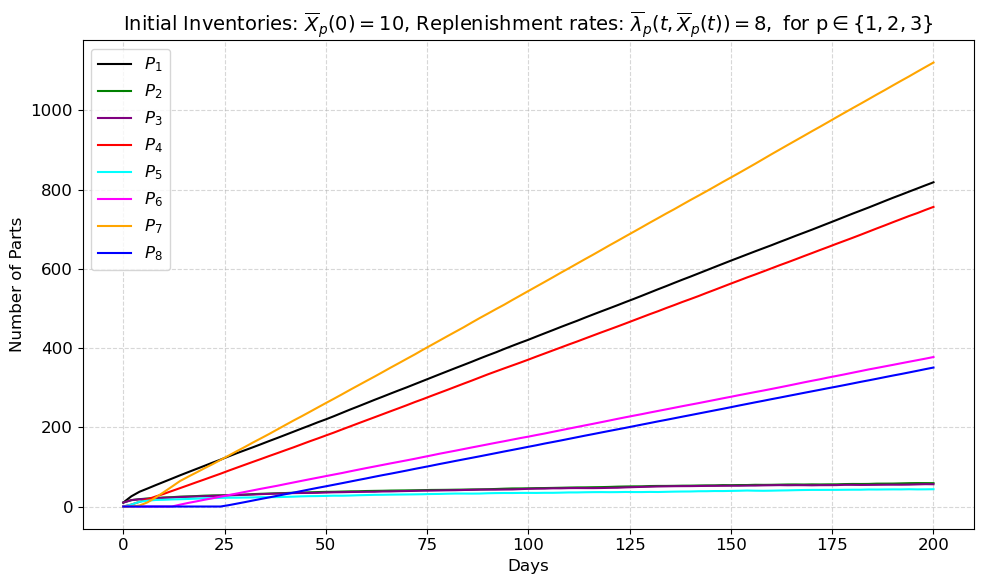

In [16]:
# initial inventories
initial_inventories = np.array([10, 10, 10, 0, 0, 0, 0, 0])

T = 200
# lambda_j values
lambda_j = np.array([8, 8, 8, 8, 8, 4, 8, 2])


#================================ Run simulation with two different taus =====================================#
taus = [2]                     # time steps
for tau in taus:
    X_avg, time = stochastic_push_system(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, initial_inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], linewidth=1.5, color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = {initial_inventories[0]}$, Replenishment rates: $\overline{{\lambda}}_p(t,\overline{{X}}_p(t)) = 8,\ \rm{{for}} \ p \in \{{1,2,3\}}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
                            
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

#===================================== Save the figure ==========================================#
    plt.savefig("Birth_process_manufacturing_SC1.png", format='png', bbox_inches='tight')  # Save before show
    plt.show()

# - Plot for $\bar{{\lambda}}_p(t,\overline{{X}}_p(t;\mu)) = 2 \rm{~for~} p \in \{1,2,3\}$

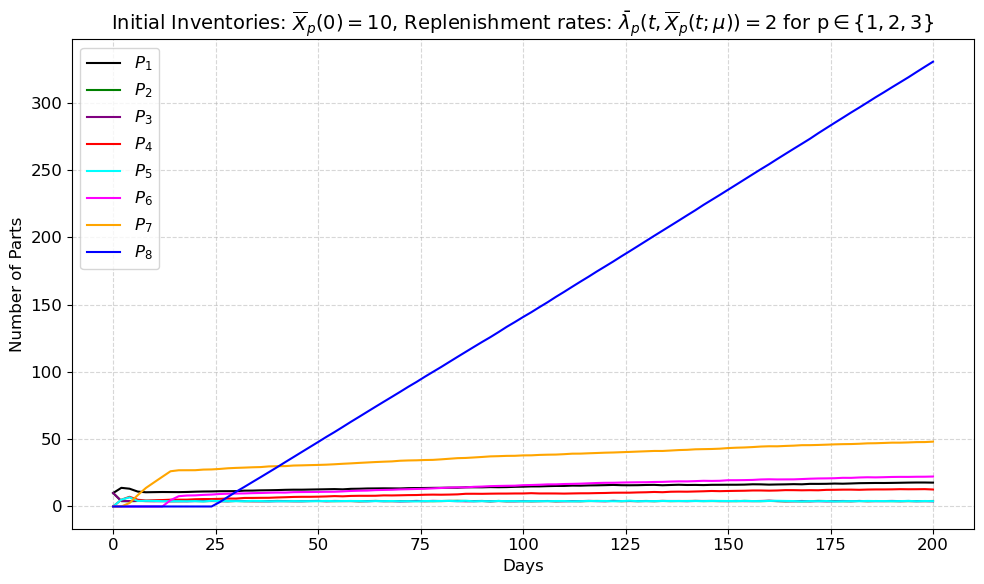

In [7]:
# initial inventories
initial_inventories = np.array([10, 10, 10, 0, 0, 0, 0, 0])

T = 200

# lambda_j values
lambda_j = np.array([2, 2, 2, 8, 8, 4, 8, 2])


# Run simulation with two different taus 
taus = [2]                     # time steps
for tau in taus:
    X_avg, time = stochastic_push_system(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, initial_inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], linewidth=1.5, color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = {initial_inventories[0]}$, Replenishment rates: $\bar{{\lambda}}_p(t,\overline{{X}}_p(t;\mu)) = 2 \ \rm{{for}} \ p \in \{{1,2,3\}}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
                            
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Save the figure
    plt.savefig("Birth_process_manufacturing_SC2.png", format='png', bbox_inches='tight')  # Save before show
    plt.show()